# DeepSeek-Foundations · Workbook 07

### The Transformer — attention, position, and the architecture behind every LLM

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~90 min · **Prereqs:** Workbooks 01, 02, 06

---

> **Abstract.** We present the transformer, the architecture behind every modern large language model, as a composition of a small set of mechanisms: scaled dot-product attention with causal masking, multi-head projections, positional encoding, and normalization with residual connections. Each mechanism is derived from a concrete failure of its predecessor — the sequential bottleneck and vanishing gradients of recurrent networks — and every claim is verified with executable NumPy demos, from the variance argument behind the $\sqrt{d_k}$ scaling to a full transformer block run end-to-end on toy tensors. We close with the two numbers that govern the field: attention's $O(T^2)$ cost and the power-law scaling of loss with parameters, and we situate DeepSeek-V2 (MLA), DeepSeek-V3 (MoE), and DeepSeek-R1 (RL reasoning) as engineering built on exactly this math.

**How this fits the series.** [Workbook 01](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) gave us the vectors, matrices, and projections that every attention score is made of; [Workbook 02](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/02_Calculus_and_Autodiff.ipynb) gave us the gradients that train the stack; [Workbook 06](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/06_Neural_Networks.ipynb) gave us the MLP that forms the feed-forward half of every block. This workbook composes them into the transformer, the architecture behind every LLM, and closes the loop back to [the master report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb). The papers ladder that follows this curriculum: Vaswani et al. 2017 → RoPE → FlashAttention → LoRA → DeepSeek-V2 (MLA) → DeepSeek-V3 (MoE) → DeepSeek-R1 — every rung is this notebook's math plus engineering.

## 1. Why sequences need attention

An LLM reads a sequence of tokens $x_1, \dots, x_T$ and must output a distribution over the next token. The pre-transformer workhorse for sequences was the **recurrent neural network (RNN)**, which maintains a hidden state updated one token at a time:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t)$$

Two structural problems follow. **Sequential bottleneck:** $h_t$ cannot be computed until $h_{t-1}$ is, so a length-$T$ sequence costs $T$ sequential steps — GPUs, which excel at parallel work, sit idle. **Vanishing gradients:** by the chain rule, the gradient of a loss at time $T$ with respect to the state at time $1$ is a product of $T-1$ Jacobians; in the scalar case it is exactly $a^{T-1}$ for a recurrence $h_t = a\,h_{t-1}$. For $|a| < 1$ the gradient dies exponentially with $T$; for $|a| > 1$ it explodes.

**The transformer bet:** drop recurrence entirely. Process all $T$ tokens in parallel through the same layers, and let tokens exchange information through a single mechanism — **attention** — which lets every token read from every other token in one step. The demo shows the gradient pathology the bet eliminates.

In [1]:

import numpy as np

# Scalar recurrence h_t = a * h_{t-1}: the gradient of h_T w.r.t. h_1 is a product
# of (T-1) factors, exactly a^(T-1). This is the vanishing/exploding gradient.
print("a      T=10          T=50          T=100")
for a in (0.9, 0.99, 1.01, 1.1):
    vals = [a ** (T - 1) for T in (10, 50, 100)]
    print(f"{a:.2f}  {vals[0]:12.3e} {vals[1]:12.3e} {vals[2]:12.3e}")
print()
print("|a| < 1  -> gradient vanishes with depth (nothing reaches token 1)")
print("|a| > 1  -> gradient explodes (training diverges)")
print("Attention replaces the product of T-1 Jacobians with a single, direct")
print("read: every token talks to every other token in one step, no chain.")


a      T=10          T=50          T=100
0.90     3.874e-01    5.726e-03    2.951e-05
0.99     9.135e-01    6.111e-01    3.697e-01
1.01     1.094e+00    1.628e+00    2.678e+00
1.10     2.358e+00    1.067e+02    1.253e+04

|a| < 1  -> gradient vanishes with depth (nothing reaches token 1)
|a| > 1  -> gradient explodes (training diverges)
Attention replaces the product of T-1 Jacobians with a single, direct
read: every token talks to every other token in one step, no chain.


## 2. Scaled dot-product attention

Attention is a content-addressed read. Each token $x_i$ is projected into three roles — a **query** $q_i = W_Q x_i$ ("what am I looking for"), a **key** $k_i = W_K x_i$ ("what do I contain"), and a **value** $v_i = W_V x_i$ ("what do I contribute"). Token $i$ reads token $j$ with weight proportional to the alignment of $q_i$ with $k_j$, then sums the values:

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V$$

**Why the $\sqrt{d_k}$?** If queries and keys have entries of variance $\sim 1$ in $d_k$ dimensions, a dot product is a sum of $d_k$ nearly independent terms, so

$$\mathrm{Var}(q_i \cdot k_j) \approx d_k, \qquad \mathrm{std}(q_i \cdot k_j) \approx \sqrt{d_k}$$

Raw scores therefore grow like $\sqrt{d_k}$, and at large $d_k$ the softmax saturates: its gradient vanishes and the read degenerates toward one-hot. Dividing by $\sqrt{d_k}$ rescales every score to variance $\sim 1$, keeping the softmax in its informative regime at any width. The demo measures exactly this: raw dot-product std tracks $\sqrt{d}$, while the scaled std stays $\approx 1$.

In [2]:

import numpy as np

rng = np.random.default_rng(7)
print("d      std(QK^T)   std(QK^T / sqrt(d))    sqrt(d)")
print("      (raw scores)   (scaled scores)")
for d in (2, 8, 32, 128):
    Q = rng.normal(size=(512, d))   # 512 random queries, entries ~ N(0, 1)
    K = rng.normal(size=(512, d))   # 512 random keys
    scores = Q @ K.T                # 512x512 raw dot products
    scaled = scores / np.sqrt(d)
    print(f"{d:4d}  {scores.std():11.3f}   {scaled.std():15.3f}   {np.sqrt(d):8.3f}")

print()
print("raw std tracks sqrt(d)  -> scores drift apart as width grows")
print("scaled std ~ 1          -> softmax inputs stay at unit scale")


d      std(QK^T)   std(QK^T / sqrt(d))    sqrt(d)
      (raw scores)   (scaled scores)
   2        1.370             0.969      1.414
   8        2.800             0.990      2.828
  32        5.627             0.995      5.657
 128       11.329             1.001     11.314

raw std tracks sqrt(d)  -> scores drift apart as width grows
scaled std ~ 1          -> softmax inputs stay at unit scale


## 3. Softmax and temperature

The softmax turns scores $z_i$ into a probability distribution:

$$\mathrm{softmax}(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

It is a **soft argmax**: the largest score gets the most mass, but every option keeps some. The shape of the distribution is controlled by a **temperature** $T$ applied before the softmax:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

As $T \to 0$ the distribution sharpens toward the argmax (greedy, low-entropy sampling); as $T \to \infty$ it flattens to uniform (exploratory, high-entropy sampling). LLMs sample at generation time with $T \approx 0.7$–$1.0$ — it is the same softmax that appears inside attention, reused as a sampling knob. The demo sharpens and flattens the logits $[2.0, 1.0, 0.1]$.

In [3]:

import numpy as np

logits = np.array([2.0, 1.0, 0.1])

def softmax(z):
    e = np.exp(z - z.max())          # subtract max for numerical stability
    return e / e.sum()

print("T      p(T)                        entropy (nats)")
for T in (0.3, 1.0, 3.0):
    p = softmax(logits / T)
    H = -(p * np.log(p)).sum()
    print(f"{T:.1f}   [{p[0]:.4f}  {p[1]:.4f}  {p[2]:.4f}]          {H:.4f}")

print()
print("T=0.3 -> nearly one-hot (greedy; low entropy)")
print("T=1.0 -> the plain softmax used in training")
print("T=3.0 -> nearly uniform (exploratory; high entropy)")


T      p(T)                        entropy (nats)
0.3   [0.9639  0.0344  0.0017]          0.1622
1.0   [0.6590  0.2424  0.0986]          0.8467
3.0   [0.4450  0.3188  0.2362]          1.0656

T=0.3 -> nearly one-hot (greedy; low entropy)
T=1.0 -> the plain softmax used in training
T=3.0 -> nearly uniform (exploratory; high entropy)


## 4. Causal masking and the shape of attention

An LLM predicts $p(x_{t+1} \mid x_1, \dots, x_t)$: token $t$ may read tokens $1 \dots t$ but never the future. The joint probability of a sequence factors left-to-right,

$$p(x_1, \dots, x_T) = \prod_{t=1}^{T} p(x_t \mid x_{<t})$$

so training must enforce this by **masking**. With batch size $B$, $H$ heads and $T$ tokens, the attention matrix has shape $(B, H, T, T)$; we set every score above the diagonal to $-\infty$ before the softmax, which forces those weights to exactly zero:

$$\mathrm{mask}(s)_{ij} = \begin{cases} s_{ij} & j \le i \\ -\infty & j > i \end{cases}$$

$-\infty$ is the trick: $\mathrm{softmax}(-\infty) = 0$ and the row still sums to $1$ — no renormalization needed. The demo runs a masked attention forward pass on a toy sequence and prints the head-0 matrix: strictly lower-triangular, with every row summing to 1.

In [4]:

import numpy as np

rng = np.random.default_rng(11)
T, d, H = 6, 8, 2
d_head = d // H

X = rng.normal(size=(T, d))                            # toy sequence, no batch
Wq = rng.normal(scale=0.2, size=(H, d, d_head))
Wk = rng.normal(scale=0.2, size=(H, d, d_head))
Wv = rng.normal(scale=0.2, size=(H, d, d_head))

Q = np.einsum("td,hde->hte", X, Wq)                    # (H, T, d_head)
K = np.einsum("td,hde->hte", X, Wk)
V = np.einsum("td,hde->hte", X, Wv)

scores = np.einsum("hte,hse->hts", Q, K) / np.sqrt(d_head)   # (H, T, T)
mask = np.triu(np.ones((T, T)), k=1).astype(bool)      # strictly upper triangle
scores[:, mask] = -np.inf                              # causal mask

def softmax_rows(A):
    e = np.exp(A - A.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attn = softmax_rows(scores)                            # (H, T, T)
np.set_printoptions(precision=3, suppress=True)
print("head 0 attention matrix (rows = query token, cols = key token):")
print(attn[0])
print()
print("row sums (should be all 1.0):", attn[0].sum(axis=-1))
print("mass on future tokens (should be 0):", attn[0, 2, 3:].sum())


head 0 attention matrix (rows = query token, cols = key token):
[[1.    0.    0.    0.    0.    0.   ]
 [0.449 0.551 0.    0.    0.    0.   ]
 [0.353 0.3   0.346 0.    0.    0.   ]
 [0.258 0.232 0.258 0.252 0.    0.   ]
 [0.225 0.225 0.2   0.149 0.201 0.   ]
 [0.196 0.22  0.139 0.073 0.162 0.21 ]]

row sums (should be all 1.0): [1. 1. 1. 1. 1. 1.]
mass on future tokens (should be 0): 0.0


## 5. Multi-head attention

One attention pass with one $(W_Q, W_K, W_V)$ triple gives one "view" of the sequence. **Multi-head attention (MHA)** runs $H$ independent attention mechanisms in parallel: the $d$-dimensional model is split into $H$ heads of size $d_h = d/H$, each with its own projections, and the outputs are concatenated and projected once more:

$$\mathrm{MHA}(X) = \big[\,\mathrm{head}_1 \parallel \dots \parallel \mathrm{head}_H\,\big] W_O, \qquad \mathrm{head}_h = \mathrm{Attention}(X W_Q^h, X W_K^h, X W_V^h)$$

Splitting is a **capacity trick**, not extra width: per head the projections are $d \times d_h$, and $H$ heads together have $3 H d (d/H) = 3d^2$ QKV parameters — the same as one wide head of size $d$. The gain is that each head lives in its own subspace and can specialize — one head tracking local co-occurrence, another long-range dependencies — and the output projection $W_O$ recombines the views. The demo runs two heads on the same 8-token sequence and shows their attention rows for token 5 disagree.

In [5]:

import numpy as np

rng = np.random.default_rng(13)
T, d, H = 8, 8, 2
d_head = d // H

X = rng.normal(size=(T, d))
Wq = rng.normal(scale=0.3, size=(H, d, d_head))
Wk = rng.normal(scale=0.3, size=(H, d, d_head))
Wv = rng.normal(scale=0.3, size=(H, d, d_head))

Q = np.einsum("td,hde->hte", X, Wq)
K = np.einsum("td,hde->hte", X, Wk)
V = np.einsum("td,hde->hte", X, Wv)
scores = np.einsum("hte,hse->hts", Q, K) / np.sqrt(d_head)
mask = np.triu(np.ones((T, T)), k=1).astype(bool)
scores[:, mask] = -np.inf

def softmax_rows(A):
    e = np.exp(A - A.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

attn = softmax_rows(scores)
print("attention over tokens for QUERY token 5, per head:")
for h in range(H):
    print(f"  head {h}: {np.round(attn[h, 5], 3)}")
cos = attn[0, 5] @ attn[1, 5] / (np.linalg.norm(attn[0, 5]) * np.linalg.norm(attn[1, 5]))
print(f"cosine similarity of the two rows: {cos:.3f}")
print("Different projections -> different attention patterns per head.")
print("Each head reads the sequence through its own subspace (d_h =", d_head, "dims).")


attention over tokens for QUERY token 5, per head:
  head 0: [0.397 0.095 0.081 0.174 0.152 0.1   0.    0.   ]
  head 1: [0.195 0.107 0.284 0.059 0.205 0.15  0.    0.   ]
cosine similarity of the two rows: 0.772
Different projections -> different attention patterns per head.
Each head reads the sequence through its own subspace (d_h = 4 dims).


## 6. Positional encoding

Attention is **permutation-equivariant**: it treats the input as an unordered set — shuffle the tokens and the same attention pattern follows the shuffle. But language is ordered ("the dog bit the cat" ≠ "the cat bit the dog"), so position must be injected explicitly. The original transformer adds a **sinusoidal positional encoding** to the token embeddings:

$$\mathrm{PE}(t, 2i) = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad \mathrm{PE}(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

Each position $t$ gets a $d$-dimensional fingerprint; dimension $i$ oscillates with wavelength $w_i = 10000^{2i/d}$, so low dimensions carry fine-grained position and high dimensions carry coarse position. A useful identity: because $\sin a \sin b + \cos a \cos b = \cos(a - b)$,

$$\mathrm{PE}(t) \cdot \mathrm{PE}(t + k) = \sum_{i=0}^{d/2 - 1} \cos\!\left(\frac{k}{w_i}\right)$$

— the similarity of two positions depends only on the **relative offset** $k$, and it decays smoothly as $k$ grows. Nearby positions are encoded as nearby vectors, which is what lets the model learn relative-position statistics.

**Modern note — RoPE.** The dominant successor is **rotary position embedding**: instead of adding position to the input, it multiplies query and key vectors by a position-dependent rotation matrix before the dot product. Rotations preserve inner products up to the angle between them, so the score between tokens $t$ and $s$ depends on position only through the relative offset $t - s$ — a strictly stronger property than absolute sinusoidal encodings — and it extrapolates to longer sequences than seen in training. No code needed: it is the same attention math, with $Q K^\top$ replaced by $(R_t Q)(R_s K)^\top$.

In [6]:

import numpy as np

T, d = 50, 16
pos = np.arange(T)[:, None]                       # (T, 1)
i = np.arange(d // 2)[None, :]                    # (1, d/2)
angle = pos / (10000.0 ** (2 * i / d))            # t / w_i,  (T, d/2)

PE = np.zeros((T, d))
PE[:, 0::2] = np.sin(angle)                       # even dims: sin
PE[:, 1::2] = np.cos(angle)                       # odd dims:  cos

print("PE[0]  :", np.round(PE[0], 3))
print("PE[1]  :", np.round(PE[1], 3))
print("PE[10] :", np.round(PE[10], 3))
print()

def cos(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

print("relative-offset similarity (smooth decay):")
for k in (1, 2, 4, 8, 16):
    print(f"  cos(PE[5], PE[5+{k:2d}]) = {cos(PE[5], PE[5 + k]):.4f}")
print()
print("Similarity depends only on k (relative offset), and falls off smoothly")
print("with k: the model can learn 'attend to nearby tokens' as a soft bias.")
print("(the shortest-wavelength dims oscillate; the long-wavelength envelope decays)")


PE[0]  : [0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.]
PE[1]  : [0.841 0.54  0.311 0.95  0.1   0.995 0.032 1.    0.01  1.    0.003 1.
 0.001 1.    0.    1.   ]
PE[10] : [-0.544 -0.839 -0.021 -1.     0.841  0.54   0.311  0.95   0.1    0.995
  0.032  1.     0.01   1.     0.003  1.   ]

relative-offset similarity (smooth decay):
  cos(PE[5], PE[5+ 1]) = 0.9356
  cos(PE[5], PE[5+ 2]) = 0.7960
  cos(PE[5], PE[5+ 4]) = 0.6950
  cos(PE[5], PE[5+ 8]) = 0.5871
  cos(PE[5], PE[5+16]) = 0.5267

Similarity depends only on k (relative offset), and falls off smoothly
with k: the model can learn 'attend to nearby tokens' as a soft bias.
(the shortest-wavelength dims oscillate; the long-wavelength envelope decays)


## 7. The full transformer block

A transformer is a stack of identical **blocks**, each composed of attention, an MLP, and two bookkeeping mechanisms. With residual connections around each sublayer and **LayerNorm** before each (the "pre-norm" arrangement used by every modern LLM):

$$x' = x + \mathrm{Attention}(\mathrm{LayerNorm}(x)), \qquad x'' = x' + \mathrm{FFN}(\mathrm{LayerNorm}(x'))$$

$$\mathrm{LayerNorm}(x)_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}, \qquad \mathrm{FFN}(x) = W_2\, \mathrm{GELU}(W_1 x + b_1) + b_2$$

where $\mu, \sigma^2$ are the per-token mean and variance. The **residual connections** give gradients a direct path backward through the stack — the identity term in $\partial x'' / \partial x = I + \cdots$ is the vanishing-gradient fix from Section 1, applied architecturally — and LayerNorm keeps activations at unit scale so the stack does not drift. The demo runs one full block in NumPy on a $(B{=}2, T{=}8, C{=}32)$ tensor and prints shapes, parameter count, and the norm before/after the block.

In [7]:

import numpy as np

rng = np.random.default_rng(17)
B, T, C, H = 2, 8, 32, 4
d_head = C // H

X = rng.normal(size=(B, T, C))                     # input activations

def layer_norm(x, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return (x - mu) / np.sqrt(var + eps)

def softmax_rows(A):
    e = np.exp(A - A.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# --- parameters of the block (all random; a real model learns these) ---
Wq = rng.normal(scale=0.1, size=(H, C, d_head))
Wk = rng.normal(scale=0.1, size=(H, C, d_head))
Wv = rng.normal(scale=0.1, size=(H, C, d_head))
Wo = rng.normal(scale=0.1, size=(H * d_head, C))
W1 = rng.normal(scale=0.1, size=(C, 4 * C)); b1 = np.zeros(4 * C)
W2 = rng.normal(scale=0.1, size=(4 * C, C)); b2 = np.zeros(C)

# --- attention sublayer ---
h = layer_norm(X)                                  # (B, T, C)
Q = np.einsum("btc,hce->bhte", h, Wq)              # (B, H, T, d_head)
K = np.einsum("btc,hce->bhte", h, Wk)
V = np.einsum("btc,hce->bhte", h, Wv)
scores = np.einsum("bhte,bhse->bhts", Q, K) / np.sqrt(d_head)   # (B,H,T,T)
mask = np.triu(np.ones((T, T)), k=1).astype(bool)
scores[:, :, mask] = -np.inf
attn = softmax_rows(scores)                        # (B, H, T, T)
ctx = np.einsum("bhts,bhse->bhte", attn, V)        # (B, H, T, d_head)
ctx = ctx.transpose(0, 2, 1, 3).reshape(B, T, H * d_head)      # (B, T, C)
attn_out = ctx @ Wo
x1 = X + attn_out                                  # residual 1

# --- MLP sublayer ---
h2 = layer_norm(x1)
ffn_hidden = np.maximum(0, h2 @ W1 + b1)       # (B, T, 4C): the 4x expansion
ffn = ffn_hidden @ W2 + b2
x2 = x1 + ffn                                      # residual 2

# --- report ---
print("shapes through the block:")
print(f"  input X        {X.shape}   (batch, tokens, channels)")
print(f"  Q, K, V       {Q.shape}   (batch, heads, tokens, d_head)")
print(f"  scores/attn   {scores.shape}   (batch, heads, tokens, tokens)")
print(f"  context       {ctx.shape}   after concat + output projection")
print(f"  FFN hidden    {ffn_hidden.shape}   4x expansion, then back to {C}")
print(f"  output x2     {x2.shape}")
print()
n_params = (Wq.size + Wk.size + Wv.size + Wo.size) + (W1.size + b1.size + W2.size + b2.size)
print(f"block parameters: {n_params:,}  (QKV {3 * H * C * d_head:,} + out proj {Wo.size:,}"
      f" + MLP {W1.size + b1.size + W2.size + b2.size:,})")
print(f"norm before: {np.linalg.norm(X):.3f}   norm after: {np.linalg.norm(x2):.3f}")
print("residuals + LayerNorm keep activation scale stable through the block")


shapes through the block:
  input X        (2, 8, 32)   (batch, tokens, channels)
  Q, K, V       (2, 4, 8, 8)   (batch, heads, tokens, d_head)
  scores/attn   (2, 4, 8, 8)   (batch, heads, tokens, tokens)
  context       (2, 8, 32)   after concat + output projection
  FFN hidden    (2, 8, 128)   4x expansion, then back to 32
  output x2     (2, 8, 32)

block parameters: 12,448  (QKV 3,072 + out proj 1,024 + MLP 8,352)
norm before: 22.648   norm after: 25.357
residuals + LayerNorm keep activation scale stable through the block


## 8. Complexity and scaling

**Attention is quadratic.** With $T$ tokens the score matrix is $T \times T$: per head it costs $O(T^2 d_h)$ flops, and summed over $H$ heads with $d_h = C/H$ the forward pass costs $\approx 4 T^2 C$ flops, with the *materialized* matrix costing $O(T^2)$ memory. Doubling the context quadruples the cost — this is why long-context LLMs are memory-bound. **FlashAttention** attacks both: the score matrix is never materialized — the softmax is computed in tiles with online rescaling, the $QK^\top$ product is fused with the $AV$ product, and the backward pass recomputes what it needs instead of storing it — turning $O(T^2)$ memory into $O(T)$ at the same compute.

**Scaling laws.** Empirically (Kaplan et al. 2020; Hoffmann et al. 2022), test loss falls as a **power law** in parameters $N$, data, and compute:

$$L(N) \approx a\, N^{-\alpha} + c$$

with $\alpha$ small (≈ 0.05–0.1) and $c$ the irreducible entropy of the data. Each doubling of $N$ buys a fixed loss reduction, which is why the field grows models exponentially. The demo prints the quadratic FLOP growth and fits this power law to synthetic points (illustrative — real fits use thousands of trained models).

T      forward attention FLOPs    growth vs T=64


   64             1.678e+07   x      1.0
  256             2.684e+08   x     16.0
 1024             4.295e+09   x    256.0
 4096             6.872e+10   x   4096.0
T=4096 costs x4096 more than T=64: O(T^2) in compute AND memory

true:   alpha = 0.1, a = 2.5, c = 1.6
fitted: alpha = 0.0950, a = 2.409, c = 1.5775   (RMS 0.0068)
loss falls a fixed amount per doubling of N -> exponential growth wins


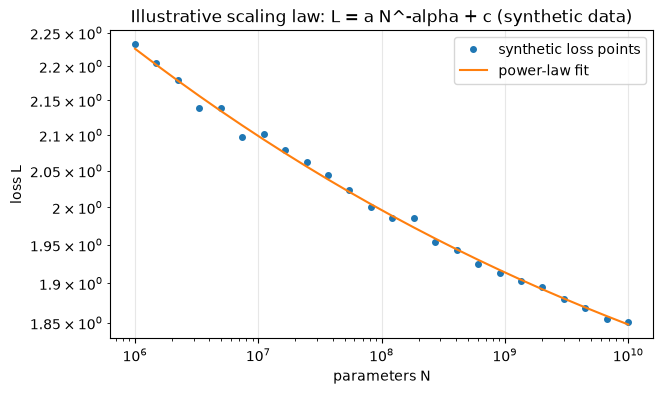

In [8]:

import numpy as np
import matplotlib.pyplot as plt

# --- quadratic attention cost ---
C = 1024  # model width; forward attention flops ~ 4 * T^2 * C
base = 4 * 64 * 64 * C
print("T      forward attention FLOPs    growth vs T=64")
for T in (64, 256, 1024, 4096):
    flops = 4 * T * T * C
    print(f"{T:5d}  {flops:20.3e}   x{flops / base:9.1f}")
print(f"T=4096 costs x{(4096 // 64) ** 2} more than T=64: O(T^2) in compute AND memory")
print()

# --- power-law scaling fit on synthetic data ---
rng = np.random.default_rng(23)
a_true, alpha_true, c_true = 2.5, 0.10, 1.6
N = np.geomspace(1e6, 1e10, 24)
loss = a_true * N ** (-alpha_true) + c_true + rng.normal(0, 0.008, size=N.size)

# fit L = a * N^-alpha + c: grid over (alpha, c), closed-form least squares for a
best = None
for alpha in np.linspace(0.02, 0.30, 57):
    for c in np.linspace(1.50, 1.70, 81):
        x = N ** (-alpha)                                # power-law term
        a = ((loss - c) * x).sum() / (x * x).sum()       # least squares for a
        rms = np.sqrt(np.mean((loss - (a * x + c)) ** 2))
        if best is None or rms < best[0]:
            best = (rms, alpha, a, c)

rms, alpha_fit, a_fit, c_fit = best
print(f"true:   alpha = {alpha_true}, a = {a_true}, c = {c_true}")
print(f"fitted: alpha = {alpha_fit:.4f}, a = {a_fit:.3f}, c = {c_fit:.4f}   (RMS {rms:.4f})")
print("loss falls a fixed amount per doubling of N -> exponential growth wins")

plt.figure(figsize=(7, 4))
plt.loglog(N, loss, "o", ms=4, label="synthetic loss points")
plt.loglog(N, a_fit * N ** (-alpha_fit) + c_fit, "-", lw=1.5, label="power-law fit")
plt.xlabel("parameters N"); plt.ylabel("loss L")
plt.title("Illustrative scaling law: L = a N^-alpha + c (synthetic data)")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 9. Where the field goes from here

**MLA (DeepSeek-V2).** Multi-head Latent Attention compresses the keys and values into a single low-rank latent vector per token instead of caching $H$ full KV pairs. The KV cache — the memory that grows linearly with context — drops by roughly 93%, which is what makes DeepSeek-V2's 236B-parameter model cheap to serve. The attention math is unchanged; only what is *stored* is factored. It is the closest published relative to KV-cache compression research, and the natural reading after this workbook.

**MoE (DeepSeek-V3).** Mixture-of-Experts replaces each MLP with many expert MLPs plus a router that sends each token to the top-$k$ experts (typically $k = 8$ of 256). Parameters grow ~16x, but FLOPs per token barely move, because compute is tied to the *active* experts. Scaling laws then apply to total parameters while the serving budget stays flat — DeepSeek-V3 trains 671B parameters for roughly the compute of a dense 37B model. The router is just a softmax over expert scores: Section 3's math, at the top of every block.

**RL reasoning (DeepSeek-R1).** R1 applies reinforcement learning directly to chain-of-thought: the model is rewarded for correct final answers on verifiable math and code, with group-relative policy optimization (GRPO) replacing a learned critic. Reasoning — longer chains, self-correction, reflection — emerges as a trained behavior without supervised examples. The transformer math did not change; what changed is the *training objective*: the softmax of Section 3 becomes a policy, and thinking longer becomes a learned strategy.

## 10. Exercises

1. **Derive the scale.** Let $q, k \in \mathbb{R}^{d_k}$ have i.i.d. entries with mean 0 and variance 1. Show that $\mathrm{Var}(q^\top k) = d_k$ and hence that $\mathrm{std}(q^\top k / \sqrt{d_k}) = 1$. *Hint: expand $\mathrm{Var}(\sum_i q_i k_i)$; independence makes variances add, and $\mathbb{E}[q_i k_i] = 0$.*

2. **Masked rows still sum to one.** In Section 4 we set masked scores to $-\infty$. Prove from the definition of softmax that every row still sums to exactly 1, then confirm numerically that `attn.sum(axis=-1)` is all ones in the demo cell.

3. **Multi-head parameters.** A single head of width $d$ has QKV projections of shape $d \times d$. Show that $H$ heads of width $d/H$ have the *same* QKV parameter count, $3d^2$. *Hint: per head it is $3 \cdot d \cdot (d/H)$; multiply by $H$.*

4. **Positional encoding inner product.** Using $\sin a \sin b + \cos a \cos b = \cos(a - b)$, show $\mathrm{PE}(t) \cdot \mathrm{PE}(t + k) = \sum_{i=0}^{d/2-1} \cos(k / w_i)$ with $w_i = 10000^{2i/d}$, and explain why the $t$ dependence cancels — similarity is a function of relative offset only.

5. **Quadratic memory.** A model holds a $T{=}1024$ attention matrix using 2 GB. Estimate the memory at $T{=}8192$ at the same width, assuming the matrix is materialized (the pre-FlashAttention regime). *Hint: $(8192/1024)^2 = 64$.*

## 11. Solutions

1. $\mathrm{Var}(\sum_i q_i k_i) = \sum_i \mathrm{Var}(q_i k_i)$ by independence. Since $\mathbb{E}[q_i] = \mathbb{E}[k_i] = 0$, we have $\mathbb{E}[q_i k_i] = 0$ and $\mathrm{Var}(q_i k_i) = \mathbb{E}[q_i^2 k_i^2] = \mathbb{E}[q_i^2]\,\mathbb{E}[k_i^2] = 1$. Summing over $d_k$ terms gives $\mathrm{Var} = d_k$, so dividing by $\sqrt{d_k}$ gives unit standard deviation — the softmax inputs stay at unit scale at any width.

2. For a masked row, only the $j \le i$ scores are finite; the $-\infty$ entries contribute $e^{-\infty} = 0$. The row becomes $\frac{e^{s_j}}{\sum_{\ell \le i} e^{s_\ell}}$ for finite entries and 0 otherwise — a normalized distribution, so the row sums to 1. Numerically, `attn.sum(axis=-1)` in the demo prints all ones.

3. Per head: Q, K, V each are $d \times (d/H)$, so $3 d (d/H)$ parameters. Across $H$ heads: $H \cdot 3 d (d/H) = 3d^2$ — identical to one wide head. The capacity gain comes from *separate subspaces* (specialization), not from more parameters.

4. Writing $\mathrm{PE}(t) \cdot \mathrm{PE}(t+k) = \sum_{i=0}^{d/2-1} \big[\sin\theta_i \sin(\theta_i + k/w_i) + \cos\theta_i \cos(\theta_i + k/w_i)\big]$ with $\theta_i = t / w_i$, the identity collapses each term to $\cos(k / w_i)$, and $t$ disappears. Two positions are similar iff they are close — a relative-position prior the model can exploit.

5. Attention memory scales as $T^2$: $(8192/1024)^2 = 64$, so ≈ 128 GB — infeasible on a single GPU. That is precisely the problem FlashAttention (no materialized matrix) and MLA (compressed KV cache) solve.

---

**Next →** [Workbook 01 — Linear Algebra](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/01_Linear_Algebra.ipynb) — the loop closes: restart the series, or climb the papers ladder (Vaswani 2017 → RoPE → FlashAttention → LoRA → MLA → MoE → R1), where every rung is this notebook's math plus engineering.

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb)